# 🧠 Laboratorio 3 – Probabilistic Retrieval: BM25 and Language Models

**Corso:** Information Retrieval – Laurea Magistrale in Informatica  
**Università:** Roma “Tor Vergata”  
**Docente:** Danilo Croce

---

## 🎯 Obiettivo del laboratorio

Nel laboratorio precedente abbiamo introdotto il **ranked retrieval** usando il **Vector Space Model**:

- documenti e query sono rappresentati come vettori
- i termini sono pesati con **TF-IDF**
- documenti e query sono confrontati con la **cosine similarity**

In questo laboratorio facciamo un passo ulteriore.

Studiamo modelli di ranking ispirati da una motivazione **probabilistica**:

1. **BM25**, uno dei modelli classici più robusti per il ranking testuale;
2. **Language Models for IR**, in cui ogni documento viene visto come un modello probabilistico che può generare la query.

L'obiettivo non è solo implementare le formule, ma capire:

- perché BM25 modifica TF-IDF;
- perché la term frequency deve saturare;
- perché la lunghezza dei documenti va normalizzata;
- perché nei language model serve lo smoothing;
- come cambiano i ranking prodotti dai diversi modelli.

---

## 📌 Collegamento con il laboratorio precedente

Nel laboratorio su TF-IDF e cosine similarity abbiamo usato uno score di questo tipo:

$$
score(q,d)=\cos(q,d)
$$

cioè una misura geometrica di somiglianza tra il vettore della query e il vettore del documento.

Con BM25 il punto di vista cambia.

Non normalizziamo più esplicitamente i vettori con la norma L2, ma assegniamo a ogni documento uno score come somma dei contributi dei termini della query:

$$
score(q,d)=\sum_{t \in q} contribution(t,d)
$$

Ogni contributo dipende da:

- quanto il termine è raro nella collezione;
- quante volte compare nel documento;
- quanto è lungo il documento.

Quindi BM25 conserva alcune intuizioni di TF-IDF, ma le modifica in modo più controllato.

---

## 🧩 Concetti principali del laboratorio

Nel notebook introdurremo progressivamente:

- term frequency grezza $tf_{t,d}$
- document frequency $df_t$
- collection frequency $cf_t$
- document length $L_d$
- average document length $\overline L$
- BM25 IDF
- saturazione della term frequency
- normalizzazione rispetto alla lunghezza del documento
- ranking con BM25
- query likelihood language model
- Dirichlet smoothing

---

## 🛠️ Struttura del notebook

Procederemo in questo ordine:

1. caricamento della stessa collezione del laboratorio precedente
2. preprocessing dei documenti
3. costruzione delle statistiche della collezione
4. intuizione della formula BM25
5. analisi del ruolo di $k_1$
6. analisi del ruolo di $b$
7. implementazione di BM25
8. ispezione dei contributi termine-per-termine
9. confronto qualitativo con TF-IDF
10. introduzione ai language model
11. smoothing con Dirichlet

---

## 🎓 Risultati di apprendimento attesi

Al termine del laboratorio lo studente dovrebbe essere in grado di:

- spiegare la differenza tra TF-IDF cosine similarity e BM25;
- calcolare le statistiche necessarie per BM25;
- implementare BM25 da zero;
- interpretare il ruolo dei parametri $k_1$ e $b$;
- spiegare perché la term frequency in BM25 cresce in modo saturante;
- spiegare perché la lunghezza del documento influenza il ranking;
- implementare un semplice query likelihood language model;
- spiegare perché serve lo smoothing;
- confrontare qualitativamente BM25 e language models.

In [ ]:
import math
import re
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.datasets import fetch_20newsgroups

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Dal modello vettoriale ai modelli probabilistici

Nel laboratorio precedente abbiamo costruito un ranking usando:

$$
tf\text{-}idf + cosine\ similarity
$$

Questa scelta è molto naturale:

- i documenti sono vettori;
- la query è un vettore;
- la rilevanza è stimata come vicinanza geometrica.

Tuttavia, il modello vettoriale lascia aperte alcune domande.

Per esempio:

- quante volte deve comparire un termine prima che il documento sia considerato molto rilevante?
- passare da 1 a 2 occorrenze è importante quanto passare da 20 a 21?
- un documento molto lungo dovrebbe essere favorito o penalizzato?
- come possiamo motivare il ranking in termini probabilistici?

BM25 nasce proprio per rispondere ad alcune di queste domande.

## Idea intuitiva di BM25

BM25 conserva alcune intuizioni di TF-IDF, ma le modifica con una motivazione probabilistica e con una gestione più controllata della term frequency e della lunghezza del documento.

Come TF-IDF, BM25 assegna più importanza ai termini rari.

Ma, diversamente dal TF-IDF più semplice:

- non usa una crescita lineare della term frequency;
- introduce una saturazione della term frequency;
- normalizza rispetto alla lunghezza del documento.

L'intuizione principale è:

> se un termine della query compare più volte in un documento, questo è un segnale di rilevanza;  
> ma dopo molte occorrenze, ulteriori ripetizioni aggiungono poca nuova evidenza.

In altre parole:

$$
1 \rightarrow 2
$$

è spesso un incremento importante, mentre

$$
100 \rightarrow 101
$$

quasi mai cambia molto la nostra opinione sulla rilevanza del documento.


## Caricamento della collezione

Per mantenere continuità con il laboratorio precedente, useremo ancora il dataset **20 Newsgroups**.

Iniziamo usando una sola categoria, `comp.graphics`, così il comportamento del ranking è più facile da analizzare.

Successivamente potremo estendere l'esperimento a più categorie.

In [ ]:
def load_collection(categories=None, subset="train"):
    """
    Carica un sottoinsieme del dataset 20 Newsgroups.

    Parameters
    ----------
    categories : list[str] or None
        Categorie da caricare.
    subset : str
        Porzione del dataset: 'train' oppure 'test'.

    Returns
    -------
    tuple
        (documents, target_names)
    """
    if categories is None:
        categories = ["comp.graphics"]

    dataset = fetch_20newsgroups(
        subset=subset,
        categories=categories,
        remove=()
    )

    return dataset.data, dataset.target_names


categories = ["comp.graphics"]

documents, target_names = load_collection(categories=categories, subset="train")

print("Selected categories:", categories)
print("Number of documents:", len(documents))

print("\nFirst raw document:\n")
print(documents[0][:1500])

Selected categories: ['comp.graphics']
Number of documents: 584

First raw document:

From: bbs.mirage@tsoft.net (Jerry Lee)
Subject: Cobra 2.0 1-b-1 Video card HELP ME!!!!
Organization: The TSoft BBS and Public Access Unix, +1 415 969 8238
Lines: 22

Does ANYONE out there in Net-land have any information on the Cobra 2.20 
card?  The sticker on the end of the card reads
        Model: Cobra 1-B-1
        Bios:  Cobra v2.20

I Havn't been able to find anything about it from anyone!  If you have 
any information on how to get a hold of the company which produces the 
card or know where any drivers are for it, PLEASE let me know!

As far as I can tell, it's a CGA card that is taking up 2 of my 16-bit 
ISA slots but when I enable the test patterns, it displays much more than 
the usualy 4 CGA colors... At least 16 from what I can count.. Thanks!

              .------------------------------------------.
              : Internet: jele@eis.calstate.edu          :
              :           

## Preprocessing

Useremo lo stesso tipo di preprocessing del laboratorio precedente, in modo da poter confrontare più facilmente i modelli.

La pipeline sarà:

- rimozione dell'header;
- lowercase;
- normalizzazione dei numeri;
- rimozione della punteggiatura;
- tokenizzazione;
- rimozione delle stopwords;
- rimozione dei token troppo corti;
- stemming.

L'obiettivo non è costruire il miglior preprocessing possibile, ma avere una rappresentazione semplice e controllabile.


In [ ]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))


def remove_header(text):
    parts = text.split("\n\n", 1)
    if len(parts) == 2:
        return parts[1]
    return text


def convert_lower_case(text):
    return text.lower()


def convert_numbers(text):
    number_map = {
        "0": " zero ",
        "1": " one ",
        "2": " two ",
        "3": " three ",
        "4": " four ",
        "5": " five ",
        "6": " six ",
        "7": " seven ",
        "8": " eight ",
        "9": " nine ",
    }
    for digit, word in number_map.items():
        text = text.replace(digit, word)
    return text


def remove_punctuation(text):
    return re.sub(r"[^\w\s]", " ", text)


def remove_extra_spaces(text):
    return re.sub(r"\s+", " ", text).strip()


def tokenize(text):
    return word_tokenize(text)


def remove_stop_words(tokens):
    return [token for token in tokens if token not in stop_words]


def remove_single_characters(tokens):
    return [token for token in tokens if len(token) > 1]


def apply_stemming(tokens):
    return [stemmer.stem(token) for token in tokens]


def preprocess(text, is_query=False):
    if not is_query:
        text = remove_header(text)

    text = convert_lower_case(text)
    text = convert_numbers(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize(text)
    tokens = remove_stop_words(tokens)
    tokens = remove_single_characters(tokens)
    tokens = apply_stemming(tokens)

    return tokens

In [ ]:
raw_example = documents[0]
processed_example = preprocess(raw_example, is_query=False)

print("First 1200 raw characters:\n")
print(raw_example[:1200])

print("\n" + "=" * 80 + "\n")

print("First 80 preprocessed tokens:\n")
print(processed_example[:80])

First 1200 raw characters:

From: bbs.mirage@tsoft.net (Jerry Lee)
Subject: Cobra 2.0 1-b-1 Video card HELP ME!!!!
Organization: The TSoft BBS and Public Access Unix, +1 415 969 8238
Lines: 22

Does ANYONE out there in Net-land have any information on the Cobra 2.20 
card?  The sticker on the end of the card reads
        Model: Cobra 1-B-1
        Bios:  Cobra v2.20

I Havn't been able to find anything about it from anyone!  If you have 
any information on how to get a hold of the company which produces the 
card or know where any drivers are for it, PLEASE let me know!

As far as I can tell, it's a CGA card that is taking up 2 of my 16-bit 
ISA slots but when I enable the test patterns, it displays much more than 
the usualy 4 CGA colors... At least 16 from what I can count.. Thanks!

              .------------------------------------------.
              : Internet: jele@eis.calstate.edu          :
              :           bbs.mirage@gilligan.tsoft.net  :
              :          

## Documenti "tokenizzati"

Applichiamo il preprocessing a tutta la collezione.

Come nel laboratorio precedente, useremo un dizionario:

$$
docID \rightarrow lista\ di\ token
$$

Questa rappresentazione è sufficiente per costruire le statistiche richieste da BM25 e dai language model.

In [ ]:
def build_tokenized_documents(documents):
    """
    Applica il preprocessing a tutti i documenti della collezione.

    Returns
    -------
    dict[int, list[str]]
        docID -> lista di token preprocessati
    """
    tokenized_documents = {}

    for doc_id, text in enumerate(documents):
        tokenized_documents[doc_id] = preprocess(text, is_query=False)

    return tokenized_documents


tokenized_documents = build_tokenized_documents(documents)

print("Number of preprocessed documents:", len(tokenized_documents))

for doc_id in range(3):
    print(f"\nDoc {doc_id} -> first 40 tokens:")
    print(tokenized_documents[doc_id][:40])

Number of preprocessed documents: 584

Doc 0 -> first 40 tokens:
['anyon', 'net', 'land', 'inform', 'cobra', 'two', 'two', 'zero', 'card', 'sticker', 'end', 'card', 'read', 'model', 'cobra', 'one', 'one', 'bio', 'cobra', 'two', 'two', 'zero', 'havn', 'abl', 'find', 'anyth', 'anyon', 'inform', 'get', 'hold', 'compani', 'produc', 'card', 'know', 'driver', 'pleas', 'let', 'know', 'far', 'tell']

Doc 1 -> first 40 tokens:
['hi', 'everyon', 'one', 'touch', 'problem', 'post', 'last', 'week', 'guess', 'question', 'clear', 'like', 'describ', 'detail', 'offset', 'ellips', 'locu', 'center', 'circl', 'roll', 'ellips', 'word', 'distanc', 'ellips', 'offset', 'everywher', 'problem', 'come', 'geometr', 'measur', 'probe', 'use', 'tip', 'probe', 'ball', 'comput', 'output', 'posit', 'ball', 'center']

Doc 2 -> first 40 tokens:
['hi', 'short', 'look', 'fast', 'assembl', 'code', 'line', 'circl', 'draw', 'svga', 'graphic', 'complet', 'think', 'simpl', 'fast', 'molecular', 'graphic', 'program', 'write', 'pc

# Statistiche della collezione

BM25 e i language model usano alcune statistiche fondamentali.

Per ogni documento $d$:

$$
L_d
$$

è la lunghezza del documento, cioè il numero di token dopo il preprocessing.

Per ogni termine $t$:

$$
tf_{t,d}
$$

è la frequenza del termine nel documento.

$$
df_t
$$

è il numero di documenti in cui il termine compare almeno una volta.

$$
cf_t
$$

è il numero totale di occorrenze del termine nell'intera collezione.

Infine:

$$
\overline L
$$

è la lunghezza media dei documenti.

Queste quantità saranno la base di tutto il laboratorio.


In [ ]:
def compute_collection_statistics(tokenized_documents):
    """
    Calcola le statistiche principali della collezione.

    Returns
    -------
    dict
        Dizionario contenente:
        - N
        - doc_lengths
        - avg_doc_len
        - term_frequencies
        - document_frequency
        - collection_frequency
        - vocabulary
        - total_tokens
    """
    N = len(tokenized_documents)

    doc_lengths = {}
    term_frequencies = {}
    document_frequency = defaultdict(int)
    collection_frequency = defaultdict(int)

    for doc_id, tokens in tokenized_documents.items():
        doc_lengths[doc_id] = len(tokens)

        tf = Counter(tokens)
        term_frequencies[doc_id] = tf

        for term, count in tf.items():
            document_frequency[term] += 1
            collection_frequency[term] += count

    avg_doc_len = sum(doc_lengths.values()) / N
    total_tokens = sum(collection_frequency.values())
    vocabulary = sorted(collection_frequency.keys())

    return {
        "N": N,
        "doc_lengths": doc_lengths,
        "avg_doc_len": avg_doc_len,
        "term_frequencies": term_frequencies,
        "document_frequency": dict(document_frequency),
        "collection_frequency": dict(collection_frequency),
        "vocabulary": vocabulary,
        "total_tokens": total_tokens,
    }


stats = compute_collection_statistics(tokenized_documents)

N = stats["N"]
doc_lengths = stats["doc_lengths"]
avg_doc_len = stats["avg_doc_len"]
term_frequencies = stats["term_frequencies"]
document_frequency = stats["document_frequency"]
collection_frequency = stats["collection_frequency"]
vocabulary = stats["vocabulary"]
total_tokens = stats["total_tokens"]

print("Number of documents:", N)
print("Vocabulary size:", len(vocabulary))
print("Total number of tokens:", total_tokens)
print("Average document length:", avg_doc_len)

Number of documents: 584
Vocabulary size: 8603
Total number of tokens: 88860
Average document length: 152.15753424657535


## Ispezione delle statistiche

Prima di implementare BM25, osserviamo alcune statistiche della collezione.

In particolare, confrontiamo:

- `df`: in quanti documenti compare un termine;
- `cf`: quante volte compare in totale nella collezione.

Un termine può avere:

- alto `cf` e alto `df`: termine diffuso;
- alto `cf` e basso `df`: termine concentrato in pochi documenti;
- basso `cf` e basso `df`: termine raro.


In [ ]:
terms_to_inspect = ["graphic", "imag", "file", "format", "window", "jpeg", "card"]

rows = []

for term in terms_to_inspect:
    rows.append({
        "term": term,
        "df": document_frequency.get(term, 0),
        "cf": collection_frequency.get(term, 0),
    })

pd.DataFrame(rows)

,term,df,cf
0,graphic,190,551
1,imag,139,792
2,file,158,543
3,format,71,272
4,window,74,166
5,jpeg,24,281
6,card,59,100


In [ ]:
top_df_terms = sorted(
    document_frequency.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

pd.DataFrame(top_df_terms, columns=["term", "df"])

,term,df
0,one,402
1,two,366
2,three,362
3,zero,330
4,four,300
5,six,279
6,five,277
7,eight,249
8,nine,240
9,edu,239


In [ ]:
top_cf_terms = sorted(
    collection_frequency.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

pd.DataFrame(top_cf_terms, columns=["term", "cf"])

,term,cf
0,one,3381
1,zero,2967
2,two,2664
3,three,2145
4,four,1657
5,five,1349
6,six,1302
7,nine,1272
8,eight,1197
9,seven,879


## Implementazione di BM25

Passiamo ora al primo modello probabilistico del laboratorio.

La formula BM25 che useremo è:

$$
BM25(d,q)
=
\sum_{t \in q^\ast}
IDF(t)
\cdot
\frac{(k_1+1)tf_{t,d}}
{k_1\left((1-b)+b\frac{L_d}{\overline L}\right)+tf_{t,d}}
$$

dove:

- $tf_{t,d}$ è la frequenza del termine nel documento;
- $L_d$ è la lunghezza del documento;
- $\overline L$ è la lunghezza media dei documenti;
- $k_1$ controlla la saturazione della term frequency;
- $b$ controlla la normalizzazione per lunghezza;
- $q^\ast$ indica l'insieme dei termini distinti della query.

Per l'IDF useremo:

$$
IDF(t)=
\log\left(
1+
\frac{N-df_t+0.5}{df_t+0.5}
\right)
$$

Questa è una variante comune che evita valori negativi dell'IDF.


Nota: Prima di implementare la classe BM25 completa, definiamo separatamente la funzione IDF per osservare alcuni valori.

In [ ]:
def bm25_idf(term, document_frequency, N):
    """
    Calcola l'IDF usato in BM25.

    Usiamo la variante:
        log(1 + (N - df + 0.5) / (df + 0.5))

    Questa forma evita IDF negativi per termini molto frequenti.

    Parameters
    ----------
    term : str
    document_frequency : dict[str, int]
    N : int

    Returns
    -------
    float
    """
    df = document_frequency.get(term, 0)

    if df == 0:
        return 0.0

    return math.log(1.0 + (N - df + 0.5) / (df + 0.5))

In [ ]:
print("Some BM25 IDF values:\n")

for term in terms_to_inspect:
    print(f"{term:12s} -> df = {document_frequency.get(term, 0):4d}, idf = {bm25_idf(term, document_frequency, N):.4f}")

Some BM25 IDF values:

graphic      -> df =  190, idf = 1.1220
imag         -> df =  139, idf = 1.4335
file         -> df =  158, idf = 1.3059
format       -> df =   71, idf = 2.1019
window       -> df =   74, idf = 2.0608
jpeg         -> df =   24, idf = 3.1729
card         -> df =   59, idf = 2.2856


In [ ]:
def print_document(doc_id, documents, max_chars=1600):
    print(f"Document {doc_id}")
    print("=" * 80)
    print(documents[doc_id][:max_chars])

## Analisi del parametro $k_1$

Il parametro $k_1$ controlla la saturazione della term frequency.

La parte della formula BM25 che dipende dalla frequenza del termine è:

$$
\frac{(k_1+1)tf}{k_1 B + tf}
$$

dove:

$$
B = (1-b)+b\frac{L_d}{\overline L}
$$

Se per semplicità consideriamo un documento di lunghezza media, allora $B=1$, e il fattore diventa:

$$
\frac{(k_1+1)tf}{k_1 + tf}
$$

Osserviamo cosa succede al variare di $k_1$.

- se $k_1$ è piccolo, la saturazione è rapida;
- se $k_1$ è grande, la saturazione è più lenta: quindi le occorrenze aggiuntive continuano ad avere effetto più a lungo;
- per $k_1=0$, conta solo la presenza del termine.


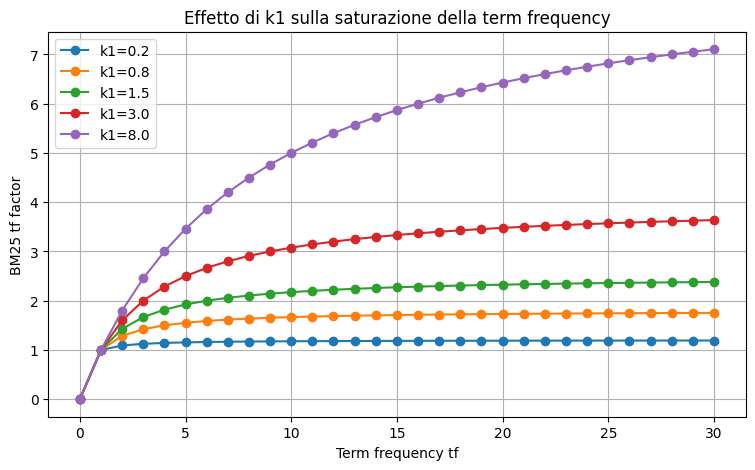

In [ ]:
def bm25_tf_factor(tf, k1=1.5, B=1.0):
    """
    Calcola il fattore di term frequency di BM25.

    Parameters
    ----------
    tf : int or float
    k1 : float
    B : float
        Fattore di normalizzazione della lunghezza.

    Returns
    -------
    float
    """
    if tf == 0:
        return 0.0

    return ((k1 + 1.0) * tf) / (k1 * B + tf)


tf_values = list(range(0, 31))
k1_values = [0.2, 0.8, 1.5, 3.0, 8.0]

plt.figure(figsize=(9, 5))

for k1 in k1_values:
    y = [bm25_tf_factor(tf, k1=k1, B=1.0) for tf in tf_values]
    plt.plot(tf_values, y, marker="o", label=f"k1={k1}")

plt.xlabel("Term frequency tf")
plt.ylabel("BM25 tf factor")
plt.title("Effetto di k1 sulla saturazione della term frequency")
plt.legend()
plt.grid(True)
plt.show()

## Interpretazione del grafico

Il grafico mostra una proprietà centrale di BM25:

$$
tf \uparrow \quad \Rightarrow \quad score \uparrow
$$

ma la crescita non è lineare.

Questo significa che:
- la prima occorrenza di un termine della query è molto importante
- le occorrenze successive continuano ad aumentare lo score
- però ogni nuova occorrenza aggiunge sempre meno evidenza

Questa proprietà si chiama **saturazione della term frequency**.

È una differenza importante rispetto a un uso troppo diretto della term frequency:
- con tf grezza, passare da 10 a 20 occorrenze raddoppia il contributo
- con BM25, passare da 10 a 20 occorrenze aumenta il contributo, ma molto meno

Questa scelta è coerente con l'intuizione probabilistica vista a lezione:

> più occorrenze sono evidenza che il documento sia collegato al termine, ma dopo un certo punto l'evidenza aggiuntiva diventa ridondante.

## Effetto della document length normalization

BM25 non usa solo la frequenza del termine nel documento.

Tiene anche conto della lunghezza del documento.

La componente di normalizzazione della lunghezza è:

$$
B_d = (1-b) + b \frac{L_d}{\overline L}
$$

dove:
- $L_d$ è la lunghezza del documento $d$
- $\overline L$ è la lunghezza media dei documenti nella collezione
- $b$ controlla quanto vogliamo normalizzare rispetto alla lunghezza.

La formula BM25 contiene $B_d$ nel denominatore:

$$
\frac{(k_1+1)tf_{t,d}}{tf_{t,d}+k_1 B_d}
$$

Quindi:
- se un documento è più lungo della media, $B_d$ aumenta
- se $B_d$ aumenta, il denominatore aumenta
- se il denominatore aumenta, il contributo del termine diminuisce

In questo modo BM25 cerca di evitare che i documenti lunghi siano favoriti solo perché contengono più parole.


In [ ]:
def bm25_tf_component(tf, doc_len, avg_doc_len, k1=1.5, b=0.75):
    """
    Calcola solo la componente di term frequency normalizzata di BM25.

    Parameters
    ----------
    tf : int or float
        Frequenza del termine nel documento.
    doc_len : int or float
        Lunghezza del documento.
    avg_doc_len : int or float
        Lunghezza media dei documenti.
    k1 : float
        Parametro di saturazione della term frequency.
    b : float
        Parametro di normalizzazione della lunghezza.

    Returns
    -------
    float
        Componente BM25 associata alla term frequency.
    """
    if tf <= 0:
        return 0.0

    B = (1 - b) + b * (doc_len / avg_doc_len)
    return ((k1 + 1) * tf) / (tf + k1 * B)

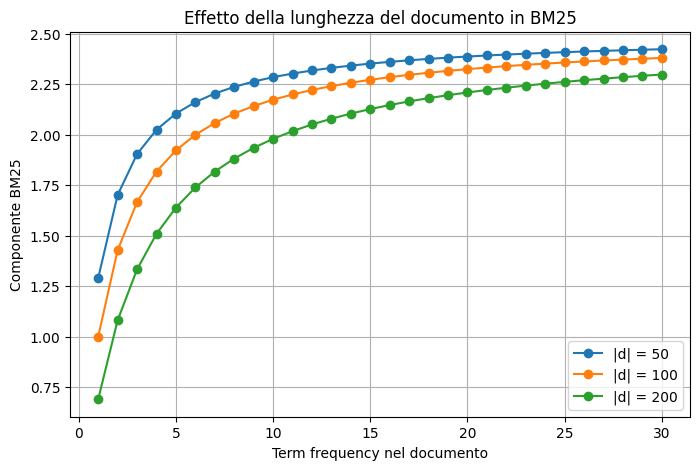

In [ ]:
tf_values = list(range(1, 31))

demo_avg_doc_len = 100
demo_doc_lengths = [50, 100, 200]

plt.figure(figsize=(8, 5))

for demo_doc_len in demo_doc_lengths:
    scores = [
        bm25_tf_component(tf, demo_doc_len, demo_avg_doc_len, k1=1.5, b=0.75)
        for tf in tf_values
    ]
    plt.plot(tf_values, scores, marker="o", label=f"|d| = {demo_doc_len}")

plt.xlabel("Term frequency nel documento")
plt.ylabel("Componente BM25")
plt.title("Effetto della lunghezza del documento in BM25")
plt.legend()
plt.grid(True)
plt.show()

## Interpretazione del secondo grafico

Nel grafico confrontiamo tre documenti:

- un documento corto: $|d| = 50$
- un documento di lunghezza media: $|d| = 100$
- un documento lungo: $|d| = 200$

Tutti hanno la stessa frequenza del termine, ma BM25 assegna contributi diversi.

A parità di $tf_{t,d}$:
- il documento corto riceve un contributo maggiore
- il documento medio riceve un contributo intermedio
- il documento lungo riceve un contributo minore

Perché?

Perché in un documento lungo è più facile osservare una parola anche solo per effetto della lunghezza.

Quindi BM25 chiede implicitamente:

> il termine compare spesso rispetto alla lunghezza del documento?

Non solo:

> il termine compare spesso in assoluto?


## Implementazione di BM25

A questo punto traduciamo la formula BM25 in codice.

La classe seguente calcola:
- term frequency per documento
- document frequency per termine
- lunghezza dei documenti
- lunghezza media
- idf probabilistico
- score BM25 per una query

In [ ]:
class BM25:
    """
    Implementazione didattica di BM25.

    Parameters
    ----------
    k1 : float
        Controlla la saturazione della term frequency.
    b : float
        Controlla la normalizzazione della lunghezza del documento.
    """

    def __init__(self, k1=1.5, b=0.75):
        self.k1 = k1
        self.b = b

    def fit(self, tokenized_documents):
        """
        Calcola le statistiche della collezione.

        Parameters
        ----------
        tokenized_documents : dict[int, list[str]]
            Dizionario doc_id -> lista di token.

        Returns
        -------
        self
        """
        self.tokenized_documents = tokenized_documents
        self.N = len(tokenized_documents)

        self.doc_len = {}
        self.term_frequencies = {}
        self.document_frequency = defaultdict(int)

        for doc_id, tokens in tokenized_documents.items():
            self.doc_len[doc_id] = len(tokens)

            tf = Counter(tokens)
            self.term_frequencies[doc_id] = tf

            for term in tf:
                self.document_frequency[term] += 1

        self.avg_doc_len = sum(self.doc_len.values()) / self.N

        return self

    def idf(self, term):
        """
        Calcola una versione non negativa dell'idf probabilistico di BM25.

        Usiamo:

        $$
        idf(t) = log(1 + (N - df_t + 0.5)/(df_t + 0.5))
        $$

        Questa variante evita valori negativi per termini molto frequenti.
        """
        df = self.document_frequency.get(term, 0)

        if df == 0:
            return 0.0

        return math.log(1 + (self.N - df + 0.5) / (df + 0.5))

    def score_term(self, term, doc_id):
        """
        Calcola il contributo di un singolo termine allo score BM25 di un documento.
        """
        tf = self.term_frequencies[doc_id].get(term, 0)

        if tf == 0:
            return 0.0

        idf = self.idf(term)
        doc_len = self.doc_len[doc_id]

        B = (1 - self.b) + self.b * (doc_len / self.avg_doc_len)

        tf_component = ((self.k1 + 1) * tf) / (tf + self.k1 * B)

        return idf * tf_component

    def score(self, query_tokens, doc_id):
        """
        Calcola lo score BM25 di un documento rispetto a una query tokenizzata.

        In questa versione semplice consideriamo ogni termine distinto della query una sola volta.
        """
        score = 0.0

        for term in sorted(set(query_tokens)):
            score += self.score_term(term, doc_id)

        return score

    def rank(self, query, top_k=10):
        """
        Restituisce i top-k documenti per una query testuale.

        Parameters
        ----------
        query : str
            Query in linguaggio naturale.
        top_k : int
            Numero di risultati da restituire.

        Returns
        -------
        tuple
            (query_tokens, ranked_results)

        dove ranked_results è una lista di tuple:
        (doc_id, score)
        """
        query_tokens = sorted(set(preprocess(query, is_query=True)))

        results = []

        for doc_id in self.tokenized_documents:
            score = self.score(query_tokens, doc_id)

            if score > 0:
                results.append((doc_id, score))

        results.sort(key=lambda x: x[1], reverse=True)

        return query_tokens, results[:top_k]

In [ ]:
bm25 = BM25(k1=1.5, b=0.75)
bm25.fit(tokenized_documents)

print("Number of documents:", bm25.N)
print("Average document length:", bm25.avg_doc_len)
print("Vocabulary size:", len(bm25.document_frequency))

Number of documents: 584
Average document length: 152.15753424657535
Vocabulary size: 8603


## Ispezioniamo alcune statistiche

Prima di usare BM25 per fare ranking, guardiamo alcune statistiche della collezione.

Per alcuni termini osserviamo:
- document frequency
- idf BM25

In [ ]:
terms_to_inspect = ["graphic", "imag", "file", "format", "window", "jpeg", "card"]

print(f"{'term':12s} {'df':>8s} {'idf':>12s}")
print("-" * 36)

for term in terms_to_inspect:
    df = bm25.document_frequency.get(term, 0)
    idf = bm25.idf(term)
    print(f"{term:12s} {df:8d} {idf:12.4f}")

term               df          idf
------------------------------------
graphic           190       1.1220
imag              139       1.4335
file              158       1.3059
format             71       2.1019
window             74       2.0608
jpeg               24       3.1729
card               59       2.2856


In [ ]:
query = "graphic file format"
query_tokens = preprocess(query, is_query=True)

doc_id = 15

print("Query tokens:", query_tokens)
print("Document:", doc_id)
print("Document length:", bm25.doc_len[doc_id])
print()

for term in sorted(set(query_tokens)):
    print(
        f"{term:12s} "
        f"tf={bm25.term_frequencies[doc_id].get(term, 0):3d} "
        f"idf={bm25.idf(term):.4f} "
        f"contribution={bm25.score_term(term, doc_id):.4f}"
    )

print("\nTotal BM25 score:", bm25.score(query_tokens, doc_id))

Query tokens: ['graphic', 'file', 'format']
Document: 15
Document length: 67

file         tf=  3 idf=1.3059 contribution=2.5305
format       tf=  5 idf=2.1019 contribution=4.4757
graphic      tf=  0 idf=1.1220 contribution=0.0000

Total BM25 score: 7.006167970333679


## Ranking con BM25

Ora possiamo usare BM25 per ordinare i documenti rispetto a una query.

Useremo una query coerente con la categoria `comp.graphics`:

```text
graphic file format
```

Osserveremo:

- query originale
- query preprocessata
-  top documenti ordinati per score BM25

In [ ]:
query = "graphic file format"

processed_query_bm25, bm25_results = bm25.rank(query, top_k=10)

print("Original query:", query)
print("Processed query:", processed_query_bm25)

print("\nTop ranked documents with BM25:\n")

for rank, (doc_id, score) in enumerate(bm25_results, start=1):
    print(f"{rank:2d}. doc {doc_id:3d} -> BM25 score = {score:.4f}")

if len(bm25_results) > 0:
    top_doc_id = bm25_results[0][0]
    print("\nTop document:\n")
    print_document(top_doc_id, documents)

Original query: graphic file format
Processed query: ['file', 'format', 'graphic']

Top ranked documents with BM25:

 1. doc 490 -> BM25 score = 7.7582
 2. doc 449 -> BM25 score = 7.5950
 3. doc 416 -> BM25 score = 7.3893
 4. doc 553 -> BM25 score = 7.2097
 5. doc 276 -> BM25 score = 7.0197
 6. doc  15 -> BM25 score = 7.0062
 7. doc 479 -> BM25 score = 6.9690
 8. doc 210 -> BM25 score = 6.9310
 9. doc 120 -> BM25 score = 6.9234
10. doc 340 -> BM25 score = 6.8513

Top document:

Document 490
From: nahess@mir.gatech.edu (Nicholas A. Hess)
Subject: Hitatchi Raster Format (HRF)?
Organization: USGS Center for Spatial Analysis Technologies
Lines: 19
NNTP-Posting-Host: mir.gatech.edu
Keywords: HRF

 Our shop uses a package called CADCore - very good - to scan and
subsequently vectorize original maps into digital maps. The problem is that
once the raster file is loaded into the CADCore package, a header is added
to the .HRF file which makes it unreadable by the supplied converter. We
would lik

## Analisi dei contributi dei termini

Per capire meglio perché un documento riceve un certo score BM25, possiamo decomporre lo score nei contributi dei singoli termini della query.

Questo è molto utile in laboratorio perché rende lo scoring meno "magico".

Per ogni termine della query mostreremo:
- tf nel documento
- df nella collezione
- idf
- contributo BM25

In [ ]:
def explain_bm25_score(bm25_model, query, doc_id):
    """
    Mostra la decomposizione dello score BM25 per un documento.
    """
    query_tokens = sorted(set(preprocess(query, is_query=True)))

    print("Query:", query)
    print("Processed query:", query_tokens)
    print("Document:", doc_id)
    print("Document length:", bm25_model.doc_len[doc_id])
    print()

    print(f"{'term':12s} {'tf':>5s} {'df':>6s} {'idf':>10s} {'contribution':>14s}")
    print("-" * 55)

    total = 0.0

    for term in query_tokens:
        tf = bm25_model.term_frequencies[doc_id].get(term, 0)
        df = bm25_model.document_frequency.get(term, 0)
        idf = bm25_model.idf(term)
        contribution = bm25_model.score_term(term, doc_id)
        total += contribution

        print(f"{term:12s} {tf:5d} {df:6d} {idf:10.4f} {contribution:14.4f}")

    print("-" * 55)
    print(f"{'TOTAL':12s} {'':5s} {'':6s} {'':10s} {total:14.4f}")

In [ ]:
query = "graphic file format"

top_doc_id = bm25_results[0][0]
explain_bm25_score(bm25, query, top_doc_id)

Query: graphic file format
Processed query: ['file', 'format', 'graphic']
Document: 490
Document length: 86

term            tf     df        idf   contribution
-------------------------------------------------------
file             2    158     1.3059         2.1686
format           4     71     2.1019         4.1947
graphic          1    190     1.1220         1.3949
-------------------------------------------------------
TOTAL                                        7.7582


## Esercizio 1 — Interpretare uno score BM25

Scegli uno dei documenti nella top-10 BM25.

Usa `explain_bm25_score` per rispondere:

1. Quale termine della query contribuisce di più allo score?
2. Il contributo maggiore dipende da `tf`, da `idf`, o da entrambi?
3. Ci sono termini della query che hanno contributo zero?
4. Il documento è lungo o corto rispetto alla media?


In [ ]:
# Modifica doc_id scegliendo un documento dalla top-10.
doc_id = bm25_results[0][0]

print_document(doc_id, documents, max_chars=1000)

explain_bm25_score(bm25, query, doc_id)

Document 490
From: nahess@mir.gatech.edu (Nicholas A. Hess)
Subject: Hitatchi Raster Format (HRF)?
Organization: USGS Center for Spatial Analysis Technologies
Lines: 19
NNTP-Posting-Host: mir.gatech.edu
Keywords: HRF

 Our shop uses a package called CADCore - very good - to scan and
subsequently vectorize original maps into digital maps. The problem is that
once the raster file is loaded into the CADCore package, a header is added
to the .HRF file which makes it unreadable by the supplied converter. We
would like to be able to ship some of the already-altered raster images for
further use on our workstations. So, here are my questions:

 (1) What is the Hitachi format? - I need this format so I can recognize
precisely what to strip out. I strongly suspect that it's a compressed
format - if so, then t might not be possible for me to strip out the
offending header.

 (2) Are there any UNIX packages that read and recognize HRF? It would be
really nice to find some sort of "hrftopbm" conve

## Nota: e la term frequency nella query?

In questa implementazione base di BM25 consideriamo ogni termine distinto della query una sola volta.

Questo è ragionevole per query brevi, come quelle tipiche dei motori di ricerca.

Per query lunghe o descrizioni più articolate si può introdurre anche un fattore di **query term frequency**, spesso controllato da un parametro indicato con $k_3$ nella formulazione classica di BM25.

In questo laboratorio lo lasciamo da parte per concentrarci sui due effetti principali:

- saturazione della term frequency nel documento;
- normalizzazione della lunghezza del documento.

## Effetto di $k_1$ sul ranking

Il parametro $k_1$ controlla la saturazione della term frequency.

Valori piccoli di $k_1$:
- saturazione più rapida
- dopo poche occorrenze, ulteriori ripetizioni contano poco

Valori grandi di $k_1$:
- saturazione più lenta
- le ripetizioni continuano a contare di più

Ora osserviamo se il ranking cambia al variare di $k_1$.

In [ ]:
query = "graphic file format"

for k1_value in [0.2, 0.8, 1.5, 3.0, 8.0]:
    model = BM25(k1=k1_value, b=0.75)
    model.fit(tokenized_documents)

    _, results = model.rank(query, top_k=5)

    print("\n" + "=" * 70)
    print(f"k1 = {k1_value}")
    print("=" * 70)

    for rank, (doc_id, score) in enumerate(results, start=1):
        print(f"{rank:2d}. doc {doc_id:3d} -> score = {score:.4f}")


k1 = 0.2
 1. doc 490 -> score = 5.0946
 2. doc 449 -> score = 5.0921
 3. doc 416 -> score = 5.0536
 4. doc 553 -> score = 5.0401
 5. doc 276 -> score = 5.0116

k1 = 0.8
 1. doc 490 -> score = 6.4977
 2. doc 449 -> score = 6.4428
 3. doc 416 -> score = 6.3124
 4. doc 553 -> score = 6.2320
 5. doc 276 -> score = 6.1208

k1 = 1.5
 1. doc 490 -> score = 7.7582
 2. doc 449 -> score = 7.5950
 3. doc 416 -> score = 7.3893
 4. doc 553 -> score = 7.2097
 5. doc 276 -> score = 7.0197

k1 = 3.0
 1. doc 490 -> score = 9.6677
 2. doc  15 -> score = 9.5419
 3. doc 210 -> score = 9.3914
 4. doc 449 -> score = 9.2285
 5. doc 116 -> score = 9.1089

k1 = 8.0
 1. doc  15 -> score = 14.4235
 2. doc 210 -> score = 14.1194
 3. doc 116 -> score = 13.1977
 4. doc 490 -> score = 12.8175
 5. doc 337 -> score = 12.0049


## Effetto di $b$ sul ranking

Il parametro $b$ controlla quanto BM25 normalizza rispetto alla lunghezza del documento.

- $b=0$: nessuna normalizzazione per lunghezza
- $b=1$: normalizzazione piena
- valori intermedi: normalizzazione parziale

Ora osserviamo se il ranking cambia al variare di $b$.

In [ ]:
query = "graphic file format"

for b_value in [0.0, 0.25, 0.75, 1.0]:
    model = BM25(k1=1.5, b=b_value)
    model.fit(tokenized_documents)

    _, results = model.rank(query, top_k=5)

    print("\n" + "=" * 70)
    print(f"b = {b_value}")
    print("=" * 70)

    for rank, (doc_id, score) in enumerate(results, start=1):
        doc_len = model.doc_len[doc_id]
        print(f"{rank:2d}. doc {doc_id:3d} -> score = {score:.4f} | len = {doc_len}")


b = 0.0
 1. doc 213 -> score = 10.9970 | len = 8402
 2. doc 366 -> score = 10.9835 | len = 6238
 3. doc 561 -> score = 10.8078 | len = 7276
 4. doc  76 -> score = 10.1722 | len = 5500
 5. doc 166 -> score = 9.1464 | len = 1253

b = 0.25
 1. doc 366 -> score = 8.7016 | len = 6238
 2. doc 213 -> score = 7.9842 | len = 8402
 3. doc  26 -> score = 7.2704 | len = 486
 4. doc 490 -> score = 7.0953 | len = 86
 5. doc 561 -> score = 7.0520 | len = 7276

b = 0.75
 1. doc 490 -> score = 7.7582 | len = 86
 2. doc 449 -> score = 7.5950 | len = 39
 3. doc 416 -> score = 7.3893 | len = 92
 4. doc 553 -> score = 7.2097 | len = 78
 5. doc 276 -> score = 7.0197 | len = 62

b = 1.0
 1. doc 449 -> score = 8.7915 | len = 39
 2. doc 490 -> score = 8.1465 | len = 86
 3. doc 276 -> score = 7.7919 | len = 62
 4. doc 416 -> score = 7.7519 | len = 92
 5. doc 553 -> score = 7.7392 | len = 78


## Osservazione

Nelle collezioni reali il ranking può cambiare anche molto al variare dei parametri.

Tuttavia, in molti casi BM25 è abbastanza robusto con valori standard come:

$$
k_1 \in [1.2, 2.0]
$$

e

$$
b \approx 0.75
$$

Questi valori non sono leggi universali.

In un sistema reale, i parametri andrebbero scelti su un development set, misurando metriche come:
- precision
- recall
- MAP
- nDCG
- MRR

## Confronto qualitativo con TF-IDF e cosine similarity

Nel laboratorio precedente abbiamo ordinato i documenti usando:

$$
cos(q,d) = \frac{q \cdot d}{||q||\ ||d||}
$$

Ora confrontiamo i risultati ottenuti con:
- cosine similarity su vettori TF-IDF
- BM25

Non ci aspettiamo necessariamente ranking identici.

I due modelli hanno intuizioni diverse:
- TF-IDF + cosine normalizza geometricamente i vettori
- BM25 usa saturazione della term frequency e normalizzazione esplicita della lunghezza

## Mini baseline TF-IDF + cosine similarity

Per confrontare BM25 con il laboratorio precedente, ricostruiamo qui una piccola baseline
TF-IDF + cosine similarity.

Questa cella rende il notebook autonomo: non dipende da funzioni definite in altri laboratori.

In [ ]:
def compute_tfidf_idf(term, document_frequency, N):
    """
    Calcola una idf semplice per TF-IDF.

    Usiamo uno smoothing leggero per evitare problemi con termini non presenti.
    """
    df = document_frequency.get(term, 0)

    if df == 0:
        return 0.0

    return math.log10(N / df)


def compute_log_tf(tf):
    """
    Peso logaritmico della term frequency.
    """
    if tf <= 0:
        return 0.0

    return 1.0 + math.log10(1.0 + tf)


def build_tfidf_document_vectors(tokenized_documents):
    """
    Costruisce:
    - document frequency
    - vettori TF-IDF sparsi dei documenti

    Returns
    -------
    tuple
        (document_vectors, document_frequency)
    """
    N = len(tokenized_documents)

    document_frequency = defaultdict(int)

    for tokens in tokenized_documents.values():
        for term in set(tokens):
            document_frequency[term] += 1

    document_vectors = {}

    for doc_id, tokens in tokenized_documents.items():
        tf = Counter(tokens)
        vec = {}

        for term, freq in tf.items():
            tf_weight = compute_log_tf(freq)
            idf_weight = compute_tfidf_idf(term, document_frequency, N)
            vec[term] = tf_weight * idf_weight

        document_vectors[doc_id] = vec

    return document_vectors, dict(document_frequency)


def build_tfidf_query_vector(query, document_frequency, N):
    """
    Costruisce il vettore TF-IDF sparso della query.
    """
    query_tokens = preprocess(query, is_query=True)
    tf = Counter(query_tokens)

    query_vector = {}

    for term, freq in tf.items():
        tf_weight = compute_log_tf(freq)
        idf_weight = compute_tfidf_idf(term, document_frequency, N)
        weight = tf_weight * idf_weight

        if weight > 0:
            query_vector[term] = weight

    return query_tokens, query_vector


def sparse_dot(vec1, vec2):
    """
    Prodotto scalare tra vettori sparsi.
    """
    if len(vec1) > len(vec2):
        vec1, vec2 = vec2, vec1

    return sum(weight * vec2.get(term, 0.0) for term, weight in vec1.items())


def sparse_norm(vec):
    """
    Norma L2 di un vettore sparso.
    """
    return math.sqrt(sum(weight * weight for weight in vec.values()))


def cosine_similarity(vec1, vec2):
    """
    Cosine similarity tra due vettori sparsi.
    """
    norm1 = sparse_norm(vec1)
    norm2 = sparse_norm(vec2)

    if norm1 == 0.0 or norm2 == 0.0:
        return 0.0

    return sparse_dot(vec1, vec2) / (norm1 * norm2)


def rank_documents_tfidf(query, document_vectors, document_frequency, top_k=10):
    """
    Ranking dei documenti con TF-IDF + cosine similarity.
    """
    N = len(document_vectors)
    query_tokens, query_vector = build_tfidf_query_vector(query, document_frequency, N)

    results = []

    for doc_id, doc_vector in document_vectors.items():
        score = cosine_similarity(query_vector, doc_vector)

        if score > 0:
            results.append((doc_id, score))

    results.sort(key=lambda x: x[1], reverse=True)

    return query_tokens, results[:top_k]

In [ ]:
tfidf_document_vectors, tfidf_document_frequency = build_tfidf_document_vectors(tokenized_documents)

print("TF-IDF baseline pronta.")
print("Number of document vectors:", len(tfidf_document_vectors))
print("Vocabulary size:", len(tfidf_document_frequency))

TF-IDF baseline pronta.
Number of document vectors: 584
Vocabulary size: 8603


In [ ]:
query = "graphic file format"

processed_query_tfidf, tfidf_results = rank_documents_tfidf(
    query,
    tfidf_document_vectors,
    tfidf_document_frequency,
    top_k=10
)

processed_query_bm25, bm25_results = bm25.rank(query, top_k=10)

print("Query:", query)
print("Processed query TF-IDF:", processed_query_tfidf)
print("Processed query BM25:  ", processed_query_bm25)

print("\nTop-10 TF-IDF + cosine:")
for rank, (doc_id, score) in enumerate(tfidf_results, start=1):
    print(f"{rank:2d}. doc {doc_id:3d} -> cosine = {score:.4f}")

print("\nTop-10 BM25:")
for rank, (doc_id, score) in enumerate(bm25_results, start=1):
    print(f"{rank:2d}. doc {doc_id:3d} -> BM25 = {score:.4f}")

Query: graphic file format
Processed query TF-IDF: ['graphic', 'file', 'format']
Processed query BM25:   ['file', 'format', 'graphic']

Top-10 TF-IDF + cosine:
 1. doc  35 -> cosine = 0.1843
 2. doc 202 -> cosine = 0.1748
 3. doc 469 -> cosine = 0.1471
 4. doc 431 -> cosine = 0.1450
 5. doc 414 -> cosine = 0.1404
 6. doc 161 -> cosine = 0.1310
 7. doc 210 -> cosine = 0.1300
 8. doc 299 -> cosine = 0.1279
 9. doc 479 -> cosine = 0.1277
10. doc 428 -> cosine = 0.1259

Top-10 BM25:
 1. doc 490 -> BM25 = 7.7582
 2. doc 449 -> BM25 = 7.5950
 3. doc 416 -> BM25 = 7.3893
 4. doc 553 -> BM25 = 7.2097
 5. doc 276 -> BM25 = 7.0197
 6. doc  15 -> BM25 = 7.0062
 7. doc 479 -> BM25 = 6.9690
 8. doc 210 -> BM25 = 6.9310
 9. doc 120 -> BM25 = 6.9234
10. doc 340 -> BM25 = 6.8513


In [ ]:
vsm_doc_id = tfidf_results[0][0]

print_document(vsm_doc_id, documents, max_chars=2000)

print("\n===================\n")

bm25_doc_id = bm25_results[0][0]

print_document(bm25_doc_id, documents, max_chars=2000)

Document 35
From: agiacalo@nmsu.edu (Toni Giacalo)
Subject: need algorithm for reading and displaying bitmap files
Organization: New Mexico State University
Lines: 7
NNTP-Posting-Host: gauss.nmsu.edu
Keywords: GIF PCX BMP

I'm making a customized paint program in DOS and need an algorithm
for reading bitmap files like GIF, PCX, or BMP.  Does anyone have
such an algorithm?  I've tried copying one out of a book for reading
.PCX format but it doesn't work.  I will take an algorithm for any
format that can be created from Windows Paint.  
Thanks!
Toni



Document 490
From: nahess@mir.gatech.edu (Nicholas A. Hess)
Subject: Hitatchi Raster Format (HRF)?
Organization: USGS Center for Spatial Analysis Technologies
Lines: 19
NNTP-Posting-Host: mir.gatech.edu
Keywords: HRF

 Our shop uses a package called CADCore - very good - to scan and
subsequently vectorize original maps into digital maps. The problem is that
once the raster file is loaded into the CADCore package, a header is added
to the .

# Language Model per Information Retrieval

BM25 non è l'unico modello probabilistico per il ranked retrieval.

Un'altra famiglia importante è quella dei **Language Models for IR**.

L'idea è diversa:

BM25 si chiede, informalmente:

> quanta evidenza forniscono i termini della query a favore della rilevanza del documento?

Il language model si chiede invece:

> quanto è probabile che la query sia stata generata dal modello linguistico del documento?

Formalmente, per un documento $d$ costruiamo un modello $M_d$ e ordiniamo i documenti secondo:

$$
p(q \mid M_d)
$$

Con una query composta dai termini $w_1,\ldots,w_m$, usando un modello unigramma:

$$
p(q \mid M_d) =
\prod_{i=1}^{m} p(w_i \mid M_d)
$$

In pratica useremo i logaritmi:

$$
\log p(q \mid M_d) =
\sum_{i=1}^{m} \log p(w_i \mid M_d)
$$

## Perché serve smoothing?

Se stimiamo la probabilità di un termine nel documento con maximum likelihood:

$$
p(t \mid M_d) = \frac{tf_{t,d}}{|d|}
$$

allora un termine non presente nel documento ha probabilità zero.

Questo è un problema grave.

Se anche un solo termine della query ha probabilità zero, allora:

$$
p(q \mid M_d)=0
$$

Il documento riceve score zero anche se contiene altri termini importanti della query.

Per evitare questo problema usiamo lo **smoothing**.

Qui implementiamo lo smoothing di Dirichlet:

$$
p(t \mid d)
=
\frac{tf_{t,d} + \mu p(t \mid C)}
{|d| + \mu}
$$

dove:
- $p(t \mid C)$ è la probabilità del termine nella collezione
- $\mu$ controlla la forza dello smoothing

Questa formula può essere letta così:

- il documento fornisce il conteggio osservato $tf_{t,d}$;
- la collezione fornisce una probabilità di background $p(t \mid C)$;
- il parametro $\mu$ decide quanto pesa il background rispetto al documento.

Se $\mu$ è grande, il modello del documento assomiglia di più al modello della collezione.  
Se $\mu$ è piccolo, il modello si fida di più delle frequenze osservate nel singolo documento.

## Query come sequenza di termini

Nel Language Model, a differenza della versione BM25 base implementata sopra, manteniamo le eventuali ripetizioni nella query.

Infatti lo score è:

$$
\log p(q \mid M_d)
=
\sum_{t \in q} \log p(t \mid M_d)
$$

Se un termine compare due volte nella query, contribuisce due volte alla log-likelihood.

Questo è coerente con l'interpretazione generativa del modello.

**Nota**: Se un termine della query non compare mai nella collezione, il modello della collezione assegna probabilità zero. In questo notebook ignoriamo questi termini fuori vocabolario, perché non aiutano a distinguere i documenti della collezione. In un sistema reale, la gestione degli out-of-vocabulary terms richiede scelte più attente.

In [ ]:
class QueryLikelihoodDirichletLM:
    """
    Language Model per IR con query likelihood e Dirichlet smoothing.

    Parameters
    ----------
    mu : float
        Parametro di smoothing Dirichlet.
    """

    def __init__(self, mu=1000.0):
        self.mu = mu

    def fit(self, tokenized_documents):
        self.tokenized_documents = tokenized_documents
        self.N = len(tokenized_documents)

        self.doc_len = {}
        self.term_frequencies = {}
        self.collection_frequency = Counter()
        self.collection_length = 0

        for doc_id, tokens in tokenized_documents.items():
            self.doc_len[doc_id] = len(tokens)

            tf = Counter(tokens)
            self.term_frequencies[doc_id] = tf

            self.collection_frequency.update(tokens)
            self.collection_length += len(tokens)

        return self

    def collection_probability(self, term):
        """
        Probabilità del termine nel modello della collezione.
        """
        cf = self.collection_frequency.get(term, 0)

        if self.collection_length == 0:
            return 0.0

        return cf / self.collection_length

    def smoothed_term_probability(self, term, doc_id):
        """
        Probabilità smoothed del termine nel documento.
        """
        tf = self.term_frequencies[doc_id].get(term, 0)
        doc_len = self.doc_len[doc_id]
        p_collection = self.collection_probability(term)

        return (tf + self.mu * p_collection) / (doc_len + self.mu)

    def score(self, query_tokens, doc_id):
        """
        Log-likelihood della query dato il documento.

        I termini fuori vocabolario vengono ignorati.
        """
        score = 0.0
        used_terms = 0

        for term in query_tokens:
            p_collection = self.collection_probability(term)

            if p_collection == 0.0:
                # Termine fuori vocabolario: non aiuta a distinguere i documenti,
                # quindi in questo notebook lo ignoriamo.
                continue

            p = self.smoothed_term_probability(term, doc_id)
            score += math.log(p)
            used_terms += 1

        if used_terms == 0:
            return float("-inf")

        return score

    def rank(self, query, top_k=10):
        query_tokens = preprocess(query, is_query=True)

        results = []

        for doc_id in self.tokenized_documents:
            score = self.score(query_tokens, doc_id)

            if score != float("-inf"):
                results.append((doc_id, score))

        results.sort(key=lambda x: x[1], reverse=True)

        return query_tokens, results[:top_k]

In [ ]:
lm = QueryLikelihoodDirichletLM(mu=100.0)
lm.fit(tokenized_documents)

query = "graphic file format"

processed_query_lm, lm_results = lm.rank(query, top_k=10)

print("Original query:", query)
print("Processed query:", processed_query_lm)

print("\nTop ranked documents with Dirichlet LM:\n")

for rank, (doc_id, score) in enumerate(lm_results, start=1):
    print(f"{rank:2d}. doc {doc_id:3d} -> LM log-score = {score:.4f}")

Original query: graphic file format
Processed query: ['graphic', 'file', 'format']

Top ranked documents with Dirichlet LM:

 1. doc 490 -> LM log-score = -12.7750
 2. doc  15 -> LM log-score = -12.8790
 3. doc 210 -> LM log-score = -12.9044
 4. doc 479 -> LM log-score = -12.9856
 5. doc 449 -> LM log-score = -13.0085
 6. doc 116 -> LM log-score = -13.0300
 7. doc 416 -> LM log-score = -13.1345
 8. doc 553 -> LM log-score = -13.2676
 9. doc 496 -> LM log-score = -13.3454
10. doc 337 -> LM log-score = -13.3742


## Confronto BM25 vs Language Model

Ora confrontiamo i top risultati ottenuti da:
- BM25
- Language Model con Dirichlet smoothing

I punteggi non sono direttamente confrontabili:
- BM25 produce uno score di ranking
- LM produce una log-likelihood

Quello che possiamo confrontare è l'ordinamento.

Nel caso del Language Model, gli score sono spesso negativi perché sono somme di log-probabilità. Anche qui vale la regola: più alto è lo score, migliore è il ranking.

In [ ]:
def compare_rankings(query, bm25_model, lm_model, top_k=10):
    """
    Confronta i ranking prodotti da BM25 e dal Language Model.
    """
    _, bm25_results = bm25_model.rank(query, top_k=top_k)
    _, lm_results = lm_model.rank(query, top_k=top_k)

    bm25_rank = {doc_id: rank for rank, (doc_id, _) in enumerate(bm25_results, start=1)}
    lm_rank = {doc_id: rank for rank, (doc_id, _) in enumerate(lm_results, start=1)}

    all_doc_ids = list(dict.fromkeys(
        [doc_id for doc_id, _ in bm25_results] +
        [doc_id for doc_id, _ in lm_results]
    ))

    rows = []

    for doc_id in all_doc_ids:
        rows.append({
            "doc_id": doc_id,
            "rank_bm25": bm25_rank.get(doc_id, "-"),
            "rank_lm": lm_rank.get(doc_id, "-"),
            "in_both": doc_id in bm25_rank and doc_id in lm_rank,
            "doc_length": bm25_model.doc_len[doc_id],
            "preview": documents[doc_id][:180].replace("\n", " ")
        })

    return pd.DataFrame(rows)

compare_rankings(query, bm25, lm, top_k=10)

,doc_id,rank_bm25,rank_lm,in_both,doc_length,preview
0,490,1,1,True,86,From: nahess@mir.gatech.edu (Nicholas A. Hess)...
1,449,2,5,True,39,From: erikb@idt.unit.no (Erik Brenn) Subject: ...
2,416,3,7,True,92,From: e-sink@uiuc.edu (Eric W. Sink) Subject: ...
3,553,4,8,True,78,From: hugo@hydra.unm.edu (patrice cummings) Su...
4,276,5,-,False,62,From: schmidt@PrakInf.TH-Ilmenau.DE (Schmidt) ...
5,15,6,2,True,67,Subject: newss From: pollarda@physc1.byu.edu D...
6,479,7,4,True,73,From: rued@daimi.aau.dk (Thomas Rued J|rgensen...
7,210,8,3,True,41,From: rubery@saturn.aitc.rest.tasc.com. (Dan R...
8,120,9,-,False,93,From: ccgwt@trentu.ca (Grant Totten) Subject: ...
9,340,10,-,False,147,From: oberto@genes.icgeb.trieste.it (Jacques O...


In [ ]:
query = "graphic file format"

_, bm25_results = bm25.rank(query, top_k=10)
_, lm_results = lm.rank(query, top_k=10)

print("Top-10 BM25:")
for rank, (doc_id, score) in enumerate(bm25_results, start=1):
    print(f"{rank:2d}. doc {doc_id:3d} -> BM25 = {score:.4f}")

print("\nTop-10 Dirichlet LM:")
for rank, (doc_id, score) in enumerate(lm_results, start=1):
    print(f"{rank:2d}. doc {doc_id:3d} -> LM = {score:.4f}")

Top-10 BM25:
 1. doc 490 -> BM25 = 7.7582
 2. doc 449 -> BM25 = 7.5950
 3. doc 416 -> BM25 = 7.3893
 4. doc 553 -> BM25 = 7.2097
 5. doc 276 -> BM25 = 7.0197
 6. doc  15 -> BM25 = 7.0062
 7. doc 479 -> BM25 = 6.9690
 8. doc 210 -> BM25 = 6.9310
 9. doc 120 -> BM25 = 6.9234
10. doc 340 -> BM25 = 6.8513

Top-10 Dirichlet LM:
 1. doc 490 -> LM = -12.7750
 2. doc  15 -> LM = -12.8790
 3. doc 210 -> LM = -12.9044
 4. doc 479 -> LM = -12.9856
 5. doc 449 -> LM = -13.0085
 6. doc 116 -> LM = -13.0300
 7. doc 416 -> LM = -13.1345
 8. doc 553 -> LM = -13.2676
 9. doc 496 -> LM = -13.3454
10. doc 337 -> LM = -13.3742


In [ ]:
bm25_top = [doc_id for doc_id, _ in bm25.rank(query, top_k=10)[1]]
lm_top = [doc_id for doc_id, _ in lm.rank(query, top_k=10)[1]]

common_docs = set(bm25_top) & set(lm_top)

print("Documenti nella top-10 di entrambi i modelli:", sorted(common_docs))
print("Numero di documenti in comune:", len(common_docs))

Documenti nella top-10 di entrambi i modelli: [15, 210, 416, 449, 479, 490, 553]
Numero di documenti in comune: 7


## Spiegazione dello score del Language Model

Come per BM25, possiamo decomporre lo score del Language Model.

Per ogni termine della query mostriamo:
- tf nel documento
- probabilità nella collezione
- probabilità smoothed nel documento
- contributo al log-score

In [ ]:
def explain_lm_score(lm_model, query, doc_id):
    query_tokens = preprocess(query, is_query=True)

    print("Query:", query)
    print("Processed query:", query_tokens)
    print("Document:", doc_id)
    print("Document length:", lm_model.doc_len[doc_id])
    print("mu:", lm_model.mu)
    print()

    print(f"{'term':12s} {'tf':>5s} {'p_coll':>12s} {'p_smooth':>12s} {'log contrib':>14s}")
    print("-" * 65)

    total = 0.0

    for term in query_tokens:
        tf = lm_model.term_frequencies[doc_id].get(term, 0)
        p_coll = lm_model.collection_probability(term)

        if p_coll == 0.0:
            print(f"{term:12s} {tf:5d} {p_coll:12.8f} {'OOV':>12s} {'ignored':>14s}")
            continue

        p_smooth = lm_model.smoothed_term_probability(term, doc_id)
        contribution = math.log(p_smooth)
        total += contribution

        print(f"{term:12s} {tf:5d} {p_coll:12.8f} {p_smooth:12.8f} {contribution:14.4f}")

    print("-" * 65)
    print(f"{'TOTAL':12s} {'':5s} {'':12s} {'':12s} {total:14.4f}")

In [ ]:
top_lm_doc_id = lm_results[0][0]
explain_lm_score(lm, query, top_lm_doc_id)

Query: graphic file format
Processed query: ['graphic', 'file', 'format']
Document: 490
Document length: 86
mu: 100.0

term            tf       p_coll     p_smooth    log contrib
-----------------------------------------------------------------
graphic          1   0.00620077   0.00871009        -4.7433
file             2   0.00611074   0.01403803        -4.2660
format           4   0.00306099   0.02315107        -3.7657
-----------------------------------------------------------------
TOTAL                                              -12.7750


## Effetto di $\mu$ nel Language Model

Il parametro $\mu$ controlla la forza dello smoothing.

- $\mu$ piccolo: il modello si fida di più del documento
- $\mu$ grande: il modello si fida di più della collezione

Se il documento è corto, lo smoothing può avere un effetto molto forte.

Ora osserviamo se il ranking cambia al variare di $\mu$.

In [ ]:
query = "graphic file format"

for mu_value in [50, 200, 1000, 3000, 10000]:
    model = QueryLikelihoodDirichletLM(mu=mu_value)
    model.fit(tokenized_documents)

    _, results = model.rank(query, top_k=5)

    print("\n" + "=" * 70)
    print(f"mu = {mu_value}")
    print("=" * 70)

    for rank, (doc_id, score) in enumerate(results, start=1):
        doc_len = model.doc_len[doc_id]
        print(f"{rank:2d}. doc {doc_id:3d} -> score = {score:.4f} | len = {doc_len}")


mu = 50
 1. doc 449 -> score = -12.1624 | len = 39
 2. doc 490 -> score = -12.2088 | len = 86
 3. doc 479 -> score = -12.3553 | len = 73
 4. doc 210 -> score = -12.4445 | len = 41
 5. doc 416 -> score = -12.6137 | len = 92

mu = 200
 1. doc  15 -> score = -13.3812 | len = 67
 2. doc 490 -> score = -13.4627 | len = 86
 3. doc 210 -> score = -13.5404 | len = 41
 4. doc 116 -> score = -13.6245 | len = 50
 5. doc 479 -> score = -13.7162 | len = 73

mu = 1000
 1. doc 366 -> score = -14.2033 | len = 6238
 2. doc  15 -> score = -14.7967 | len = 67
 3. doc 213 -> score = -14.9234 | len = 8402
 4. doc 490 -> score = -14.9488 | len = 86
 5. doc 210 -> score = -14.9714 | len = 41

mu = 3000
 1. doc 366 -> score = -14.3799 | len = 6238
 2. doc 213 -> score = -15.0723 | len = 8402
 3. doc  15 -> score = -15.4498 | len = 67
 4. doc 575 -> score = -15.4768 | len = 882
 5. doc 166 -> score = -15.5276 | len = 1253

mu = 10000
 1. doc 366 -> score = -14.8224 | len = 6238
 2. doc 213 -> score = -15.3683

In [ ]:
def search_all(query, bm25_model, lm_model, top_k=5):
    """
    Esegue la stessa query con BM25 e Language Model.
    """
    print("Query:", query)
    print("=" * 80)

    _, bm25_results = bm25_model.rank(query, top_k=top_k)
    _, lm_results = lm_model.rank(query, top_k=top_k)

    print("\nBM25")
    print("-" * 80)
    for rank, (doc_id, score) in enumerate(bm25_results, start=1):
        print(f"{rank:2d}. doc {doc_id:3d} | score = {score:10.4f} | len = {bm25_model.doc_len[doc_id]}")

    print("\nLanguage Model with Dirichlet smoothing")
    print("-" * 80)
    for rank, (doc_id, score) in enumerate(lm_results, start=1):
        print(f"{rank:2d}. doc {doc_id:3d} | score = {score:10.4f} | len = {lm_model.doc_len[doc_id]}")

In [ ]:
queries = [
    "graphic file format",
    "jpeg image compression",
    "window manager graphics",
    "rendering software",
    "image display color",
]

for q in queries:
    print("\n" + "#" * 90)
    search_all(q, bm25, lm, top_k=3)


##########################################################################################
Query: graphic file format

BM25
--------------------------------------------------------------------------------
 1. doc 490 | score =     7.7582 | len = 86
 2. doc 449 | score =     7.5950 | len = 39
 3. doc 416 | score =     7.3893 | len = 92

Language Model with Dirichlet smoothing
--------------------------------------------------------------------------------
 1. doc 490 | score =   -12.7750 | len = 86
 2. doc  15 | score =   -12.8790 | len = 67
 3. doc 210 | score =   -12.9044 | len = 41

##########################################################################################
Query: jpeg image compression

BM25
--------------------------------------------------------------------------------
 1. doc 366 | score =    13.5166 | len = 6238
 2. doc 178 | score =    13.4926 | len = 82
 3. doc   6 | score =    10.0883 | len = 38

Language Model with Dirichlet smoothing
------------------------

# Perché nei Language Model i termini comuni pesano poco?

A prima vista, nei Language Model sembra mancare un termine esplicito di tipo IDF.

BM25 contiene direttamente un fattore come:

$$
IDF(t)
$$

mentre nel query likelihood model usiamo:

$$
\log p(q \mid M_d)
=
\sum_{k=1}^{|q|}
\log p(w_k \mid M_d)
$$

oppure, in forma bag-of-words:

$$
\log p(q \mid M_d)
=
\sum_{t:\,tf_{t,q}>0}
tf_{t,q}\log p(t \mid M_d)
$$

Quindi può sembrare che un termine molto comune, come `the`, sia favorito perché ha probabilità alta.

Il punto importante è che, quando usiamo lo smoothing, il modello del documento viene confrontato implicitamente con il **background della collezione**.

Nel caso di Dirichlet smoothing:

$$
p_{\mathrm{Dir}}(t \mid d)
=
\frac{tf_{t,d}+\mu p(t \mid C)}
{|d|+\mu}
$$

dove:

- $tf_{t,d}$ è il numero di occorrenze di $t$ nel documento $d$;
- $p(t\mid C)$ è la probabilità del termine nella collezione;
- $\mu$ controlla la forza dello smoothing.

Riscriviamo la formula mettendo in evidenza il contributo del background:

$$
p_{\mathrm{Dir}}(t \mid d)
=
\frac{\mu p(t\mid C)}{|d|+\mu}
\left(
1+
\frac{tf_{t,d}}{\mu p(t\mid C)}
\right)
$$

Passando ai logaritmi:

$$
\log p_{\mathrm{Dir}}(t \mid d)
=
\log
\frac{\mu p(t\mid C)}{|d|+\mu}
+
\log
\left(
1+
\frac{tf_{t,d}}{\mu p(t\mid C)}
\right)
$$

Il secondo termine:

$$
\log
\left(
1+
\frac{tf_{t,d}}{\mu p(t\mid C)}
\right)
$$

misura quanto il documento aumenta la probabilità del termine rispetto al background della collezione.

Se un termine è molto comune nella collezione, allora $p(t\mid C)$ è grande.  
Di conseguenza, il rapporto

$$
\frac{tf_{t,d}}{\mu p(t\mid C)}
$$

è piccolo, e quindi il guadagno prodotto da quel termine è piccolo.

Se invece un termine è raro nella collezione, allora $p(t\mid C)$ è piccolo.  
Di conseguenza, anche una sola occorrenza nel documento può produrre un guadagno grande.

Quindi nei Language Model con smoothing non c'è un IDF esplicito, ma c'è un effetto simile:

> i termini rari producono un guadagno maggiore rispetto al modello della collezione.

Attenzione però: lo score completo contiene anche il denominatore dello smoothing Dirichlet.

Infatti:

$$
p_{\mathrm{Dir}}(t\mid d)
=
\frac{tf_{t,d}+\mu p(t\mid C)}
{|d|+\mu}
$$

e quindi:

$$
\log p_{\mathrm{Dir}}(t\mid d)
=
\log\left(tf_{t,d}+\mu p(t\mid C)\right)
-
\log(|d|+\mu)
$$

Per una query con $|q|$ termini:

$$
\log p_{\mathrm{Dir}}(q\mid d)
=
\sum_{k=1}^{|q|}
\log p_{\mathrm{Dir}}(w_k\mid d)
$$

cioè:

$$
\log p_{\mathrm{Dir}}(q\mid d)
=
\sum_{k=1}^{|q|}
\log\left(tf_{w_k,d}+\mu p(w_k\mid C)\right)
-
|q|\log(|d|+\mu)
$$

Quindi il ranking non dipende solo dai termini presenti nel documento.

Dipende da due effetti:

1. un termine raro dà un guadagno maggiore quando compare nel documento;
2. il denominatore $|d|+\mu$ introduce una normalizzazione legata alla lunghezza del documento.

In sintesi:

- i termini comuni hanno probabilità alta nel background, quindi aggiungono poca evidenza specifica;
- i termini rari hanno probabilità bassa nel background, quindi quando compaiono nel documento sono più informativi;
- Dirichlet smoothing introduce anche una normalizzazione rispetto alla lunghezza del documento.

Per questo motivo, nei Language Model non serve necessariamente un IDF esplicito: parte del comportamento dell'IDF emerge dal confronto tra documento e collezione.

In [ ]:
# Esempio numerico: termini comuni vs termini rari nei Language Model

import math

def dirichlet_term_probability(tf_td, p_collection, doc_len, mu):
    return (tf_td + mu * p_collection) / (doc_len + mu)

def dirichlet_gain(tf_td, p_collection, mu):
    """
    Termine di guadagno:
        log(1 + tf_td / (mu * p_collection))

    Misura quanto il documento aumenta la probabilità del termine
    rispetto al background della collezione.
    """
    return math.log(1 + tf_td / (mu * p_collection))

mu = 1000
doc_len = 100

examples = [
    {
        "term": "the",
        "type": "common term",
        "p_collection": 0.05,
        "tf_td": 5,
    },
    {
        "term": "jpeg",
        "type": "rare term",
        "p_collection": 0.0005,
        "tf_td": 1,
    },
]

rows = []

for ex in examples:
    term = ex["term"]
    p_collection = ex["p_collection"]
    tf_td = ex["tf_td"]

    p_dir = dirichlet_term_probability(
        tf_td=tf_td,
        p_collection=p_collection,
        doc_len=doc_len,
        mu=mu
    )

    log_p_dir = math.log(p_dir)

    gain = dirichlet_gain(
        tf_td=tf_td,
        p_collection=p_collection,
        mu=mu
    )

    rows.append({
        "term": term,
        "type": ex["type"],
        "tf_td": tf_td,
        "p_collection": p_collection,
        "mu * p_collection": mu * p_collection,
        "p_dirichlet": p_dir,
        "log_p_dirichlet": log_p_dir,
        "gain_vs_background": gain,
    })

pd.DataFrame(rows)

,term,type,tf_td,p_collection,mu * p_collection,p_dirichlet,log_p_dirichlet,gain_vs_background
0,the,common term,5,0.0500,50.0,0.050000,-2.995732,0.095310
1,jpeg,rare term,1,0.0005,0.5,0.001364,-6.597600,1.098612


Nell'esempio, `the` ha una probabilità assoluta più alta:

$$
p_{\mathrm{Dir}}(\texttt{the}\mid d)
>
p_{\mathrm{Dir}}(\texttt{jpeg}\mid d)
$$

quindi il suo log-score è meno negativo.

Ma questo non significa che `the` sia più informativo per il ranking.

Infatti, `the` è già molto probabile nel background della collezione.  
Il documento non aggiunge molta evidenza nuova.

Il termine `jpeg`, invece, è raro nel background.  
Se compare anche una sola volta nel documento, aumenta molto di più la probabilità rispetto a ciò che ci aspettavamo dalla collezione.

Per questo motivo è utile guardare il guadagno:

$$
\log
\left(
1+
\frac{tf_{t,d}}{\mu p(t\mid C)}
\right)
$$

Questo termine mostra l'effetto simile all'IDF nei Language Model:

- termini comuni: guadagno piccolo;
- termini rari: guadagno grande.

# Esercizi finali

## Esercizio 1 — Cambiare query

Prova query diverse, per esempio:

- `jpeg image compression`
- `window manager graphics`
- `rendering software`
- `computer animation file`
- `image display color`

Per ogni query confronta:

- top-5 BM25
- top-5 Language Model

Domande guida:

1. I due modelli restituiscono gli stessi documenti?
2. Quali documenti compaiono in entrambi i ranking?
3. I documenti molto corti appaiono spesso nelle prime posizioni? Oppure vengono penalizzati?
4. Quale modello sembra penalizzare di più i documenti che non contengono tutti i termini della query?

---

## Esercizio 2 — Analizzare $k_1$

Modifica il parametro $k_1$ in BM25 usando valori come:

$$
0.2,\ 0.8,\ 1.5,\ 3.0,\ 8.0
$$

Domande guida:

1. Il ranking cambia?
2. Quali documenti rimangono stabili nella top-5?
3. I documenti con molte ripetizioni dei termini della query vengono favoriti di più quando $k_1$ cresce?

---

## Esercizio 3 — Analizzare $b$

Modifica il parametro $b$ usando valori come:

$$
0.0,\ 0.25,\ 0.75,\ 1.0
$$

Domande guida:

1. Cosa succede ai documenti lunghi?
2. Cosa succede ai documenti corti?
3. In quali query la normalizzazione della lunghezza sembra più importante?

---

## Esercizio 4 — Analizzare $\mu$ nel Language Model

Modifica il parametro $\mu$ usando valori come:

$$
50,\ 200,\ 1000,\ 3000,\ 10000
$$

Domande guida:

1. Con $\mu$ piccolo, quali documenti vengono favoriti?
2. Con $\mu$ molto grande, le differenze tra documenti si attenuano?
3. Quali documenti sono più sensibili allo smoothing?

## Riassunto del laboratorio

In questo laboratorio abbiamo introdotto due modelli probabilistici per il ranked retrieval.

### BM25

BM25 assegna a ogni documento uno score basato su:

- importanza del termine nella collezione tramite idf
- frequenza del termine nel documento
- saturazione della term frequency
- normalizzazione della lunghezza del documento

La formula di base è:

$$
BM25(d,q)
=
\sum_{t \in q^\ast}
IDF(t)
\cdot
\frac{(k_1+1)tf_{t,d}}
{k_1\left((1-b)+b\frac{L_d}{\overline L}\right)+tf_{t,d}}
$$

dove $q^\ast$ indica l'insieme dei termini distinti della query.

### Language Model

Il modello query likelihood ordina i documenti secondo:

$$
p(q \mid M_d)
$$

Con Dirichlet smoothing:

$$
p(t \mid d)
=
\frac{tf_{t,d} + \mu p(t \mid C)}
{|d|+\mu}
$$

### Messaggio chiave

Rispetto al Vector Space Model, questi modelli cambiano il punto di vista:

- TF-IDF + cosine similarity interpreta il retrieval come un problema geometrico
- BM25 interpreta il ranking come una combinazione robusta di evidenza lessicale, rarità del termine, saturazione della frequenza e normalizzazione della lunghezza
- i Language Models interpretano il retrieval come probabilità di generare la query dal documento

In pratica, BM25 rimane uno dei modelli più forti, semplici e robusti per il first-stage retrieval.